# 03 — Analyse exploratoire (EDA)

**Objectif :** comprendre la dynamique commerciale avant la modélisation : tendance et saisonnalité, pays et catégories qui portent le CA, retours, distribution des prix et effet des promotions.

**Méthode :** les agrégations sont calculées **dans SQL Server** (6,4 M de lignes ne sont jamais chargées en mémoire). Tous les montants sont en **USD** via la vue `warehouse.vw_Fact_Sales_USD`.

**Définitions :** CA brut = ventes ; CA net = ventes − retours. Mars 2025 (incomplet) est exclu des analyses mensuelles.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

from src.db import get_engine, read_sql
from src.plotting import PALETTE, PRIMARY, millions, set_style

set_style()
engine = get_engine()

## 1. KPI globaux

In [2]:
kpis = read_sql("""
    SELECT
        SUM(CASE WHEN Transaction_Type = 'Sale'   THEN Line_Total_USD ELSE 0 END)  AS Gross_Revenue_USD,
        -SUM(CASE WHEN Transaction_Type = 'Return' THEN Line_Total_USD ELSE 0 END) AS Returns_USD,
        SUM(Line_Total_USD)                                                        AS Net_Revenue_USD,
        COUNT(DISTINCT CASE WHEN Transaction_Type = 'Sale' THEN Invoice_ID END)    AS Orders,
        COUNT(DISTINCT Customer_Key)                                               AS Customers
    FROM warehouse.vw_Fact_Sales_USD
""", engine).iloc[0]

pd.Series({
    "CA brut (USD)": f"{kpis['Gross_Revenue_USD']:,.0f}",
    "Retours (USD)": f"{kpis['Returns_USD']:,.0f}",
    "CA net (USD)": f"{kpis['Net_Revenue_USD']:,.0f}",
    "Commandes": f"{kpis['Orders']:,.0f}",
    "Clients acheteurs": f"{kpis['Customers']:,.0f}",
    "Panier moyen (USD)": f"{kpis['Gross_Revenue_USD'] / kpis['Orders']:,.2f}",
    "Taux de retour (en valeur)": f"{kpis['Returns_USD'] / kpis['Gross_Revenue_USD']:.1%}",
}, name="Valeur").to_frame()

,Valeur
CA brut (USD),"298,688,435"
Retours (USD),"16,694,432"
CA net (USD),"281,994,003"
Commandes,"4,337,270"
Clients acheteurs,"1,283,707"
Panier moyen (USD),68.87
Taux de retour (en valeur),5.6%


## 2. Tendance et saisonnalité

In [3]:
monthly = read_sql("""
    SELECT d.[Year], d.[Month],
           SUM(CASE WHEN f.Transaction_Type = 'Sale' THEN f.Line_Total_USD ELSE 0 END) AS Gross_Revenue_USD,
           SUM(f.Line_Total_USD)                                                     AS Net_Revenue_USD,
           COUNT(DISTINCT CASE WHEN f.Transaction_Type = 'Sale' THEN f.Invoice_ID END) AS Orders
    FROM warehouse.vw_Fact_Sales_USD AS f
    JOIN warehouse.Dim_Date AS d ON d.Date_Key = f.Date_Key
    GROUP BY d.[Year], d.[Month]
    ORDER BY d.[Year], d.[Month]
""", engine)
monthly["Period"] = pd.to_datetime(dict(year=monthly["Year"], month=monthly["Month"], day=1))
monthly = monthly[monthly["Period"] < "2025-03-01"]  # mars 2025 incomplet

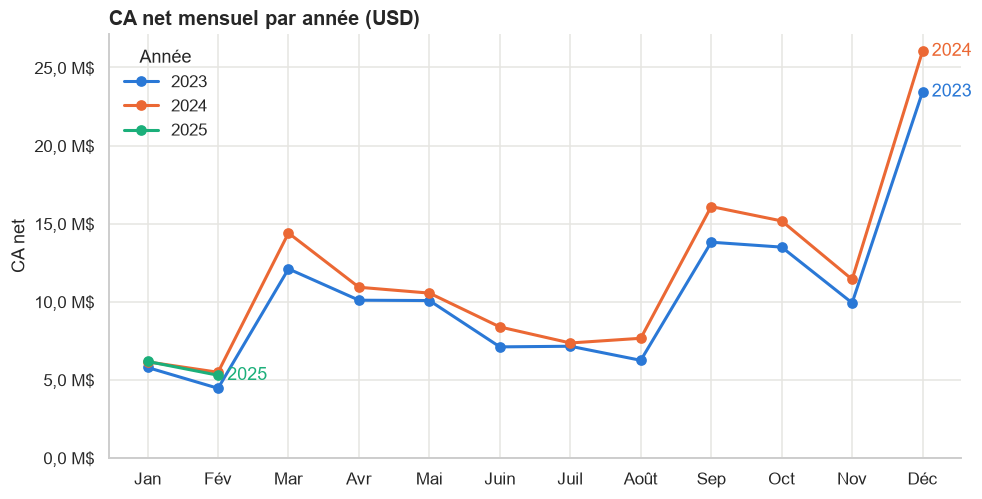

In [4]:
fig, ax = plt.subplots()
for color, (year, data) in zip(PALETTE, monthly.groupby("Year")):
    ax.plot(data["Month"], data["Net_Revenue_USD"], marker="o", color=color, label=str(year))
    ax.annotate(str(year), (data["Month"].iloc[-1], data["Net_Revenue_USD"].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", color=color)

ax.set_xticks(range(1, 13), ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
                             "Juil", "Août", "Sep", "Oct", "Nov", "Déc"])
ax.yaxis.set_major_formatter(millions())
ax.set_ylim(bottom=0)
ax.set_title("CA net mensuel par année (USD)")
ax.set_ylabel("CA net")
ax.legend(title="Année", frameon=False)
plt.show()

In [5]:
yoy = monthly.pivot(index="Month", columns="Year", values="Net_Revenue_USD")
print(f"Croissance 2024 vs 2023 : {yoy[2024].sum() / yoy[2023].sum() - 1:+.1%}")
print(f"Décembre = {yoy.loc[12].mean() / yoy.drop(index=12).mean().mean():.1f}x le mois moyen (hors décembre)")

Croissance 2024 vs 2023 : +12.9%
Décembre = 3.0x le mois moyen (hors décembre)


**À retenir :**
- Saisonnalité très marquée et **identique d'une année sur l'autre** : pics en mars et en septembre-octobre (changements de collection), et surtout **décembre** (fêtes), qui pèse environ 3 fois un mois moyen ; creux en janvier-février.
- La courbe 2024 est au-dessus de 2023 presque tous les mois (croissance annuelle d'environ +13 %).
- Implication pour la prévision (notebook 06) : le modèle doit capter **tendance + saisonnalité annuelle**, avec seulement 2 cycles complets d'historique.

## 3. Où se fait le CA : pays et catégories

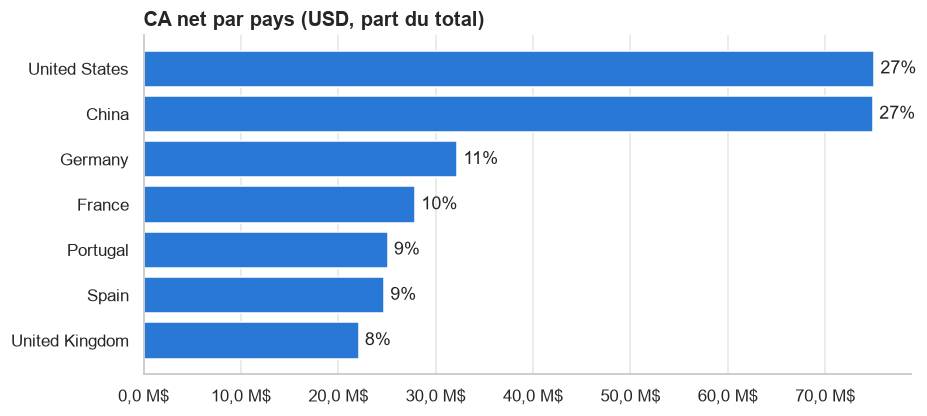

In [6]:
by_country = read_sql("""
    SELECT s.Country, SUM(f.Line_Total_USD) AS Net_Revenue_USD
    FROM warehouse.vw_Fact_Sales_USD AS f
    JOIN warehouse.Dim_Store AS s ON s.Store_Key = f.Store_Key
    GROUP BY s.Country
""", engine).sort_values("Net_Revenue_USD")
by_country["Share"] = by_country["Net_Revenue_USD"] / by_country["Net_Revenue_USD"].sum()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(by_country["Country"], by_country["Net_Revenue_USD"], color=PRIMARY)
ax.bar_label(bars, labels=[f"{s:.0%}" for s in by_country["Share"]], padding=4)
ax.xaxis.set_major_formatter(millions())
ax.set_title("CA net par pays (USD, part du total)")
ax.grid(axis="y", visible=False)
plt.show()

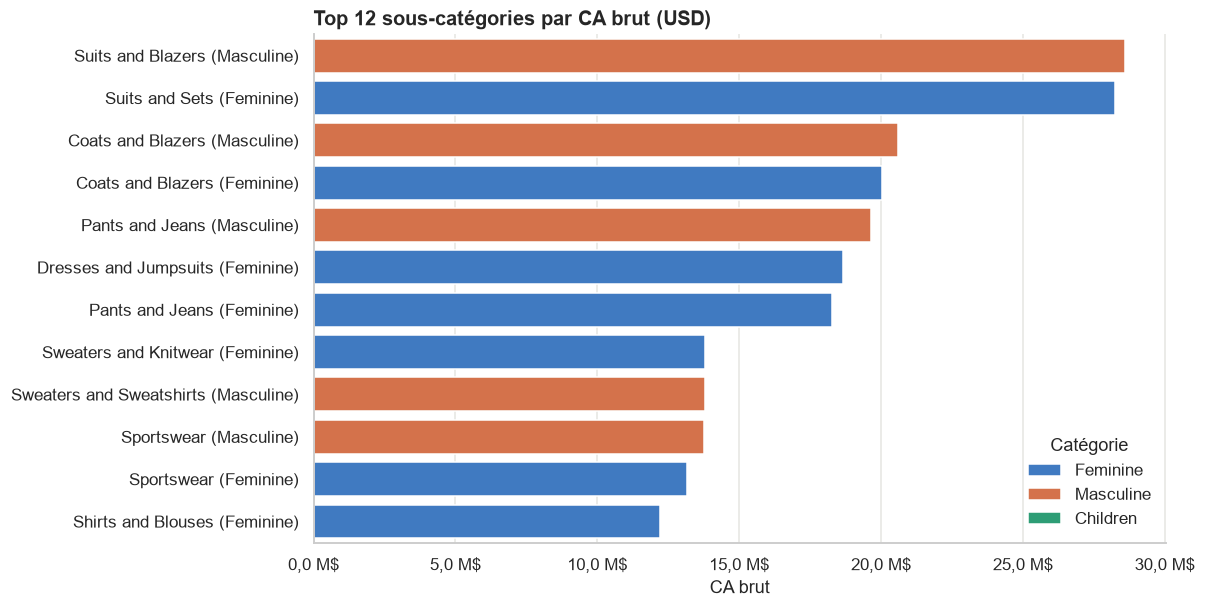

In [7]:
by_subcategory = read_sql("""
    SELECT p.Category, p.Sub_Category,
           SUM(f.Line_Total_USD)                                        AS Revenue_USD,
           SUM(f.Line_Total_USD) - SUM(f.Quantity * p.Production_Cost)  AS Gross_Profit_USD
    FROM warehouse.vw_Fact_Sales_USD AS f
    JOIN warehouse.Dim_Product AS p ON p.Product_Key = f.Product_Key
    WHERE f.Transaction_Type = 'Sale'
    GROUP BY p.Category, p.Sub_Category
""", engine)
by_subcategory["Margin"] = by_subcategory["Gross_Profit_USD"] / by_subcategory["Revenue_USD"]

# Une même sous-catégorie existe dans plusieurs catégories : le libellé combine les deux.
top = by_subcategory.nlargest(12, "Revenue_USD")
top["Label"] = top["Sub_Category"] + " (" + top["Category"] + ")"
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top, y="Label", x="Revenue_USD", hue="Category",
            hue_order=["Feminine", "Masculine", "Children"], dodge=False, ax=ax)
ax.xaxis.set_major_formatter(millions())
ax.set_title("Top 12 sous-catégories par CA brut (USD)")
ax.set_xlabel("CA brut")
ax.set_ylabel("")
ax.legend(title="Catégorie", frameon=False)
plt.show()

In [8]:
by_category = by_subcategory.groupby("Category")[["Revenue_USD", "Gross_Profit_USD"]].sum()
by_category["Margin"] = by_category["Gross_Profit_USD"] / by_category["Revenue_USD"]
by_category.sort_values("Revenue_USD", ascending=False).style.format(
    {"Revenue_USD": "{:,.0f}", "Gross_Profit_USD": "{:,.0f}", "Margin": "{:.1%}"}
)

,Revenue_USD,Gross_Profit_USD,Margin
Category,,,
Feminine,"147,984,856","90,541,222",61.2%
Masculine,"124,154,769","76,730,974",61.8%
Children,"26,548,810","15,528,802",58.5%


**À retenir :**
- **États-Unis et Chine réalisent chacun 27 % du CA** (5 magasins chacun) ; les 5 pays européens se partagent le reste (8 à 11 % chacun). Ce classement n'a de sens qu'en USD : en devise locale, la Chine (prix en CNY ~7x plus élevés) écraserait artificiellement les autres pays.
- Les **costumes** dominent : « Suits and Blazers » (homme) et « Suits and Sets » (femme) font chacun ~28 M$, devant les manteaux, pantalons et robes. L'**enfant** ne pèse que 9 % du CA et n'apparaît pas dans le top 12.
- **Marge brute d'environ 61 %**, homogène entre féminin et masculin (un peu plus faible sur l'enfant : 58,5 %), sous l'hypothèse d'un coût de production exprimé en USD.

## 4. Retours

In [9]:
returns_by_subcategory = read_sql("""
    SELECT p.Category, p.Sub_Category,
           -SUM(CASE WHEN f.Transaction_Type = 'Return' THEN f.Line_Total_USD ELSE 0 END)
            / NULLIF(SUM(CASE WHEN f.Transaction_Type = 'Sale' THEN f.Line_Total_USD ELSE 0 END), 0) AS Return_Rate
    FROM warehouse.vw_Fact_Sales_USD AS f
    JOIN warehouse.Dim_Product AS p ON p.Product_Key = f.Product_Key
    GROUP BY p.Category, p.Sub_Category
""", engine)

ranked = returns_by_subcategory.sort_values("Return_Rate", ascending=False)
pd.concat([ranked.head(3), ranked.tail(3)]).style.format({"Return_Rate": "{:.2%}"}).hide(axis="index")

Category,Sub_Category,Return_Rate
Masculine,Sportswear,5.69%
Masculine,Underwear and Pajamas,5.68%
Feminine,Sweaters and Knitwear,5.65%
Masculine,T-shirts and Polos,5.53%
Children,Coats,5.51%
Children,Pajamas,5.41%


Le taux de retour en valeur est **quasiment identique pour les 26 sous-catégories** (entre 5,4 % et 5,7 % ; 5,6 % au global). Dans ce dataset synthétique, les retours semblent tirés aléatoirement plutôt que liés au produit : ce n'est pas un levier d'action par catégorie. Sur des données réelles, on s'attendrait à des écarts nets (par exemple sur les pantalons, sensibles à la taille), qui orienteraient les actions : guide des tailles, photos produit, qualité.

## 5. Distribution des prix et valeurs extrêmes

Échantillon d'environ 200 000 lignes de vente. L'échantillonnage est **déterministe** (hash de la clé) : il est reproductible, et évite le coûteux `ORDER BY NEWID()` sur 6 M de lignes.

In [10]:
sample = read_sql("""
    SELECT f.Unit_Price_USD, f.Quantity, f.Discount, f.Line_Total_USD, p.Category
    FROM warehouse.vw_Fact_Sales_USD AS f
    JOIN warehouse.Dim_Product AS p ON p.Product_Key = f.Product_Key
    WHERE f.Transaction_Type = 'Sale'
      AND ABS(CHECKSUM(f.Sale_Key)) % 30 = 0
""", engine)
print(f"{len(sample):,} lignes échantillonnées")

202,495 lignes échantillonnées


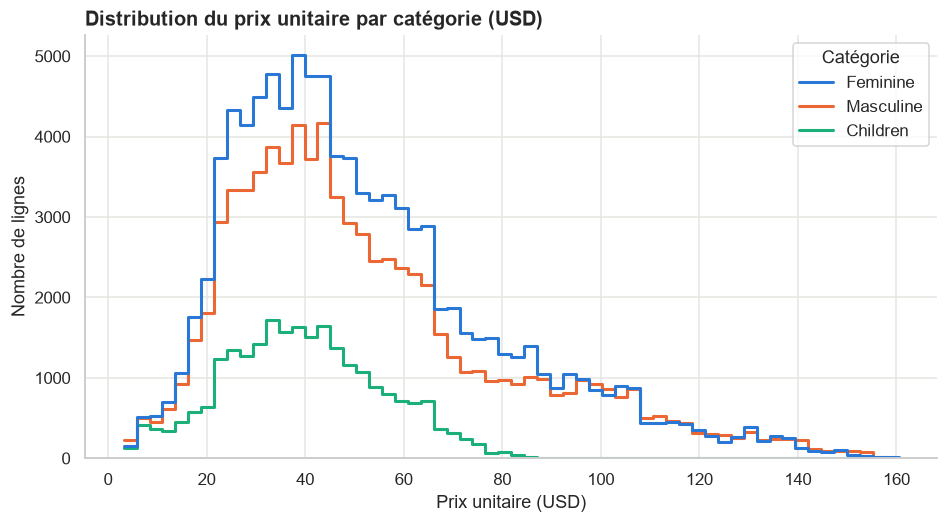

In [11]:
fig, ax = plt.subplots()
sns.histplot(data=sample, x="Unit_Price_USD", hue="Category",
             hue_order=["Feminine", "Masculine", "Children"],
             bins=60, element="step", fill=False, ax=ax)
ax.get_legend().set_title("Catégorie")
ax.set_title("Distribution du prix unitaire par catégorie (USD)")
ax.set_xlabel("Prix unitaire (USD)")
ax.set_ylabel("Nombre de lignes")
plt.show()

In [12]:
def iqr_outliers(series: pd.Series) -> pd.Series:
    q1, q3 = series.quantile([0.25, 0.75])
    upper = q3 + 1.5 * (q3 - q1)
    return pd.Series({"Seuil haut (IQR)": upper, "Part au-dessus": (series > upper).mean(), "Max": series.max()})

sample[["Unit_Price_USD", "Line_Total_USD"]].apply(iqr_outliers).T.style.format(
    {"Seuil haut (IQR)": "{:.2f}", "Part au-dessus": "{:.1%}", "Max": "{:.2f}"}
)

,Seuil haut (IQR),Part au-dessus,Max
Unit_Price_USD,111.79,3.9%,160.45
Line_Total_USD,111.60,5.4%,476.97


In [13]:
sample["Quantity"].value_counts(normalize=True).sort_index().rename("Part des lignes")

Quantity
1    0.933974
2    0.032796
3    0.033230
Name: Part des lignes, dtype: float64

**À retenir :**
- Distribution des prix **asymétrique à droite** (quelques articles premium), cohérente avec un catalogue de mode.
- La règle IQR signale 3,9 % des prix au-dessus de 112 $, mais le maximum (160 $) reste un prix plausible pour un costume et l'audit n'a trouvé aucune valeur invalide : ce sont des **articles premium, pas des erreurs**. Ils sont **conservés** (les supprimer biaiserait le CA à la baisse).
- 93 % des lignes portent sur une seule unité : la quantité apporte peu de variance, le CA est porté par le **prix** et le **nombre de commandes** (4,3 millions de commandes, panier moyen de 69 $).

## 6. Les promotions augmentent-elles les quantités achetées ?

Hypothèses : H0 « la distribution des quantités est identique avec ou sans remise » vs H1 « elle diffère ». Test de **Mann-Whitney** (la quantité est discrète et très asymétrique, un test t sur la moyenne serait inadapté).

In [14]:
has_discount = sample["Discount"] > 0
with_discount = sample.loc[has_discount, "Quantity"]
without_discount = sample.loc[~has_discount, "Quantity"]

u_stat, p_value = stats.mannwhitneyu(with_discount, without_discount, alternative="two-sided")
# Taille d'effet : probabilité qu'une ligne remisée ait une quantité supérieure à une ligne non remisée (0,5 = aucun effet)
effect_size = u_stat / (len(with_discount) * len(without_discount))

pd.DataFrame({
    "Lignes": [len(with_discount), len(without_discount)],
    "Quantité moyenne": [with_discount.mean(), without_discount.mean()],
    "Part multi-unités": [(with_discount > 1).mean(), (without_discount > 1).mean()],
}, index=["Avec remise", "Sans remise"]).style.format(
    {"Lignes": "{:,}", "Quantité moyenne": "{:.3f}", "Part multi-unités": "{:.1%}"}
)

,Lignes,Quantité moyenne,Part multi-unités
Avec remise,"59,845",1.099,6.6%
Sans remise,"142,650",1.099,6.6%


In [15]:
print(f"Mann-Whitney U : p-value = {p_value:.3f} ; taille d'effet (P(X > Y)) = {effect_size:.3f}")

Mann-Whitney U : p-value = 0.653 ; taille d'effet (P(X > Y)) = 0.500


**Interprétation :** quantité moyenne identique (1,099) et même part de lignes multi-unités (6,6 %) avec ou sans remise ; p-value = 0,65 et taille d'effet de 0,500 : **aucun effet**. **Les remises n'augmentent pas le nombre d'articles par ligne** : elles réduisent le prix sans effet volume visible à ce niveau.

**Limites :** étude observationnelle — les remises ciblent des périodes et des catégories précises (soldes), donc la comparaison n'est pas causale. L'effet d'une promotion pourrait aussi passer par **plus de commandes** (trafic) plutôt que par plus d'articles par ligne, ce que ce test ne mesure pas ; une analyse avant/après par période promotionnelle (`Dim_Discount`) serait l'étape suivante.

## Conclusions de l'EDA

1. **Croissance et saisonnalité fortes et régulières** (pic de décembre) -> la prévision doit modéliser la saisonnalité annuelle.
2. **CA concentré** : États-Unis et Chine (54 % à eux deux), costumes et manteaux -> priorités naturelles pour le pilotage.
3. **Retours uniformes** (5,6 % du CA, identiques entre produits) et **promotions sans effet sur les quantités** : leur intérêt éventuel est à chercher du côté du trafic (nombre de commandes), pas du panier.
4. **Aucune valeur aberrante à corriger** : les valeurs extrêmes sont des articles premium légitimes.